In [1]:
# =========================
# CELL A: SET PATHS
# =========================

# ---- NI TTL folder ----
ni_folder = r"C:\Users\Shermanlab\Desktop\2026-03-05_09-27-03\Record Node 106\experiment2\recording1\events\NI-DAQmx-105.PXIe-6341\TTL"

# ---- Phy (Kilosort output) ----
phy_path = r"C:\Users\Shermanlab\Desktop\2026-03-05_09-27-03\Record Node 101\experiment2\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4"

print("NI folder:")
print(ni_folder)

print("\nPhy path:")
print(phy_path)

NI folder:
C:\Users\Shermanlab\Desktop\2026-03-05_09-27-03\Record Node 106\experiment2\recording1\events\NI-DAQmx-105.PXIe-6341\TTL

Phy path:
C:\Users\Shermanlab\Desktop\2026-03-05_09-27-03\Record Node 101\experiment2\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4


✅ Units loaded: 10

Unit 109
  spikes: 67796
  bursts: 47
  burst rate: 0.013 Hz
  % spikes in bursts: 0.18%

Unit 288
  spikes: 56956
  bursts: 49
  burst rate: 0.013 Hz
  % spikes in bursts: 0.21%

Unit 118
  spikes: 48100
  bursts: 203
  burst rate: 0.054 Hz
  % spikes in bursts: 1.27%

Unit 86
  spikes: 46430
  bursts: 263
  burst rate: 0.071 Hz
  % spikes in bursts: 1.46%

Unit 341
  spikes: 42378
  bursts: 8
  burst rate: 0.002 Hz
  % spikes in bursts: 0.04%

Unit 64
  spikes: 41186
  bursts: 759
  burst rate: 0.204 Hz
  % spikes in bursts: 5.34%

Unit 12
  spikes: 40289
  bursts: 22
  burst rate: 0.006 Hz
  % spikes in bursts: 0.14%

Unit 10
  spikes: 38447
  bursts: 744
  burst rate: 0.200 Hz
  % spikes in bursts: 5.19%

Unit 225
  spikes: 14078
  bursts: 331
  burst rate: 0.089 Hz
  % spikes in bursts: 5.58%

Unit 263
  spikes: 524
  bursts: 0
  burst rate: 0.000 Hz
  % spikes in bursts: 0.00%


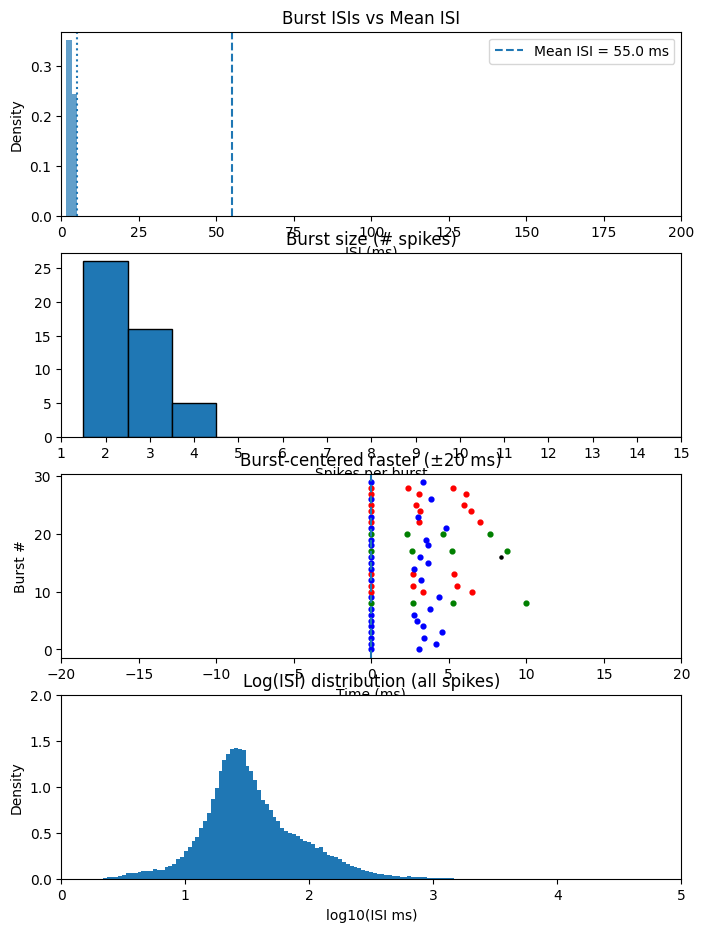

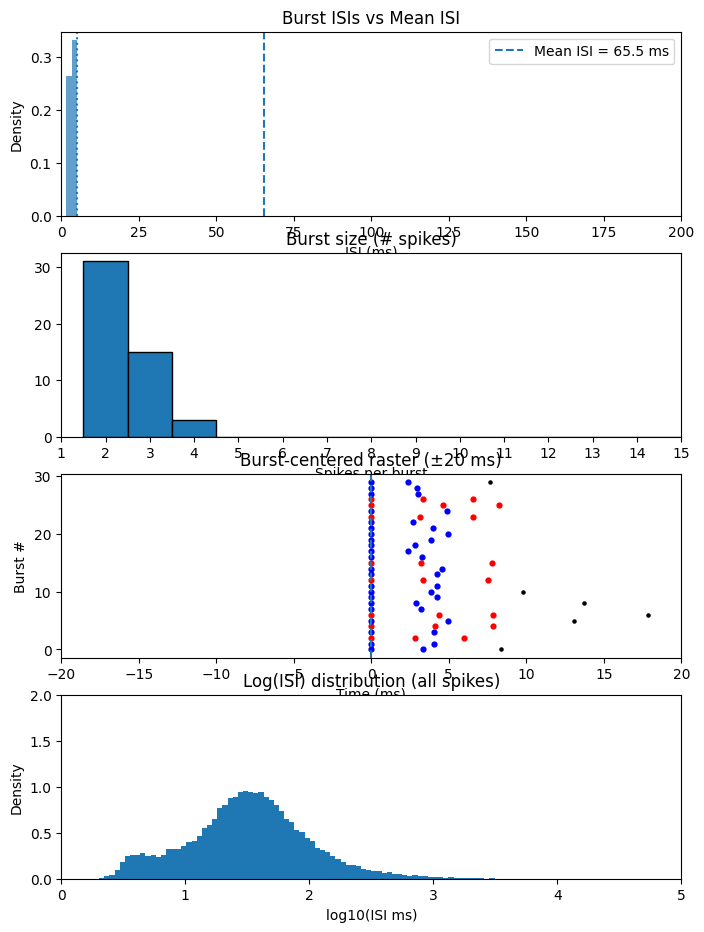

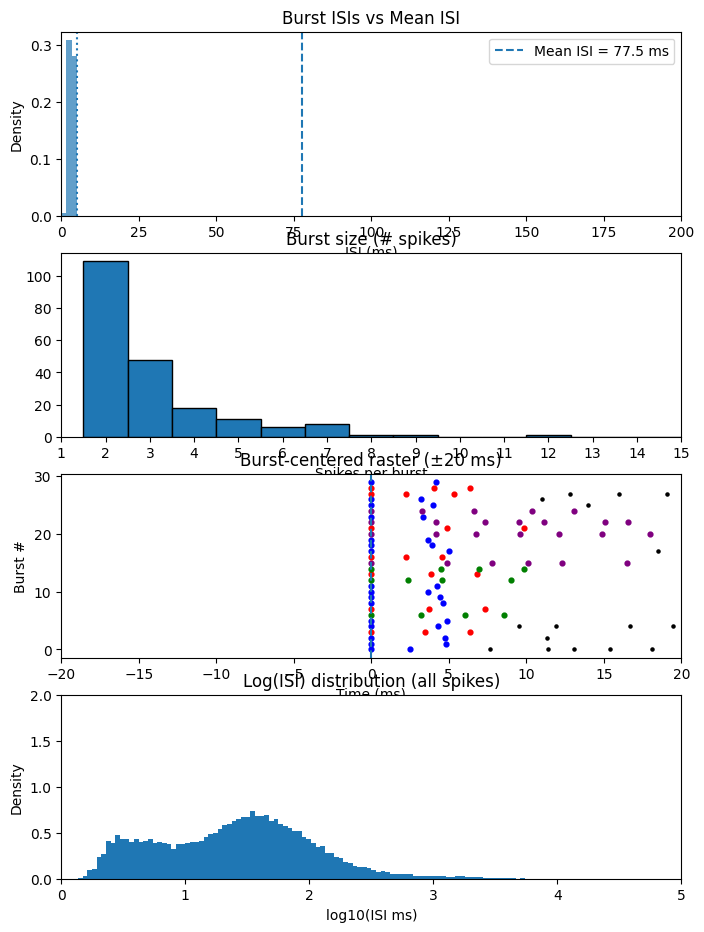

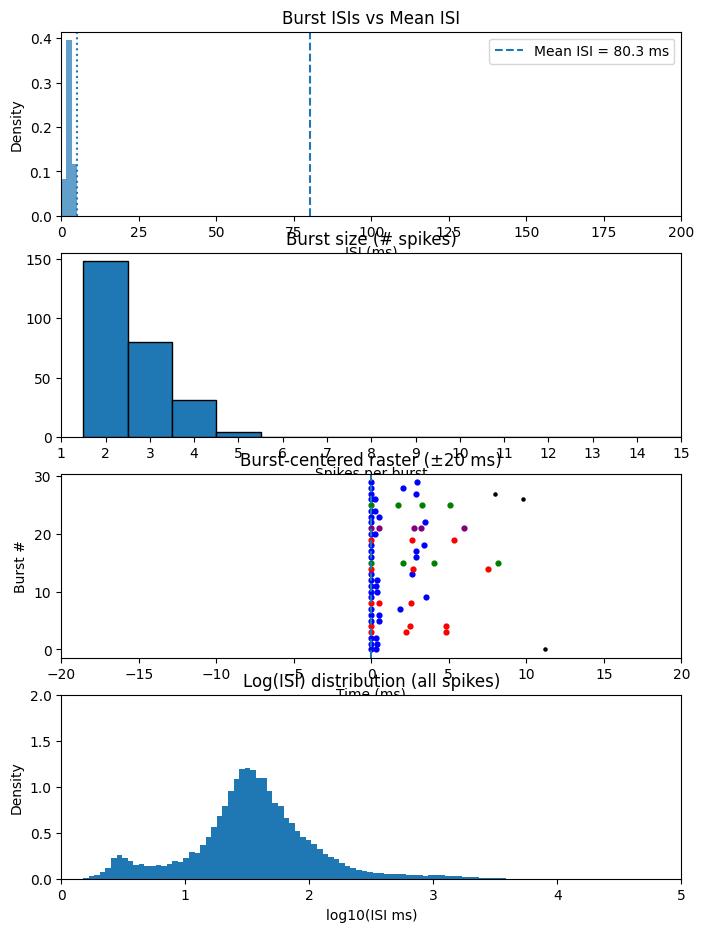

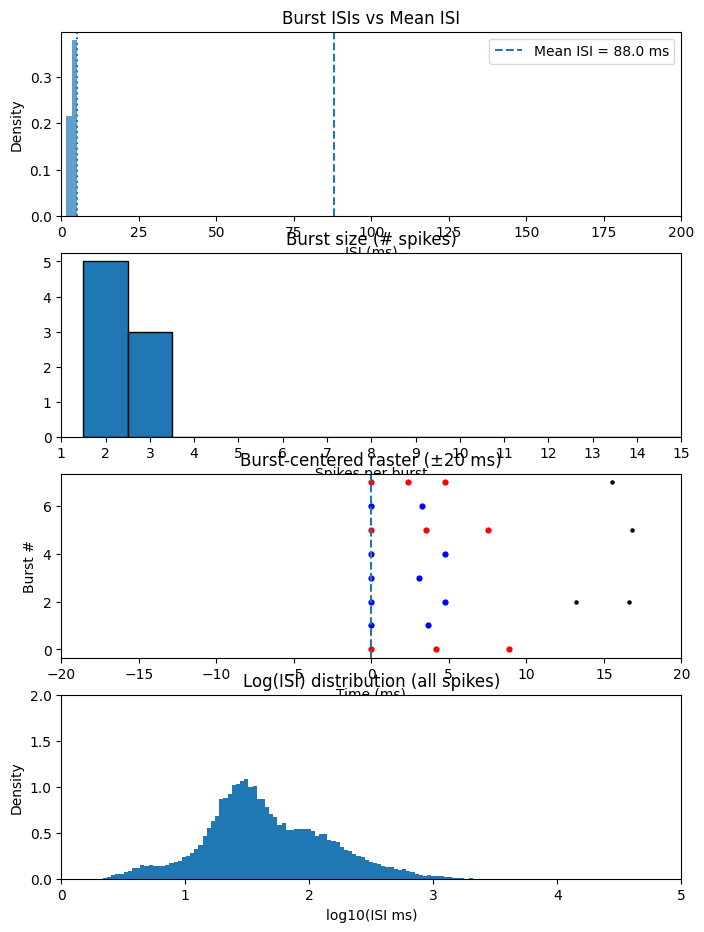

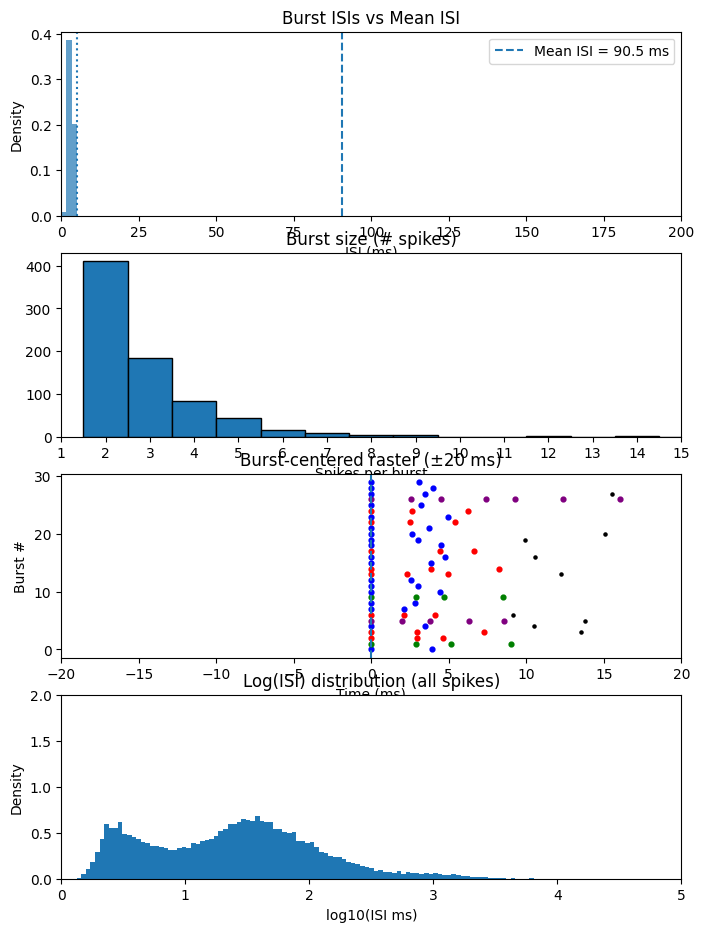

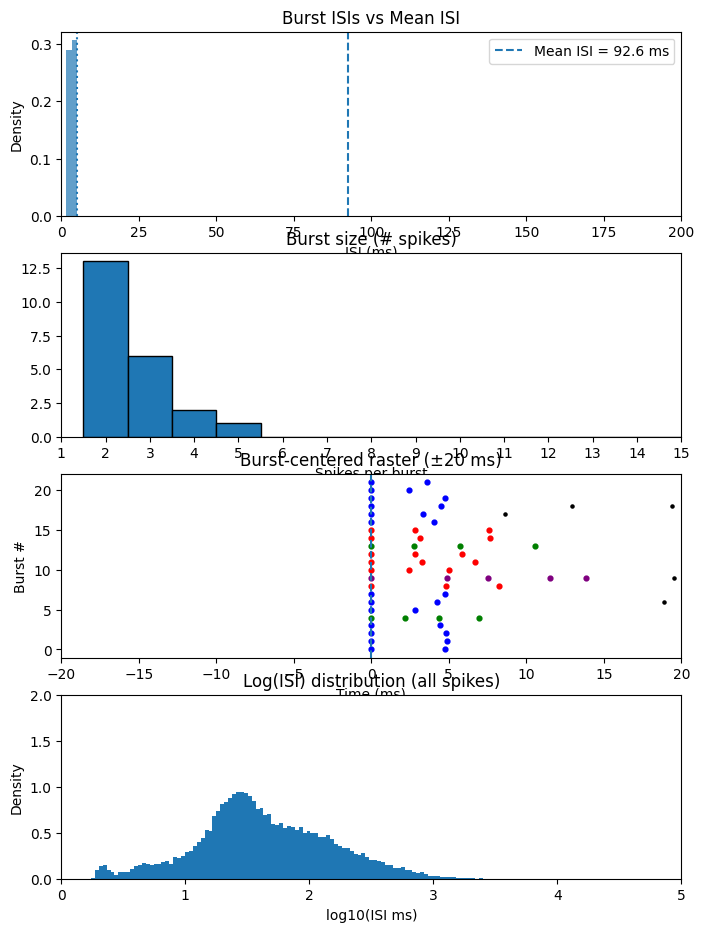

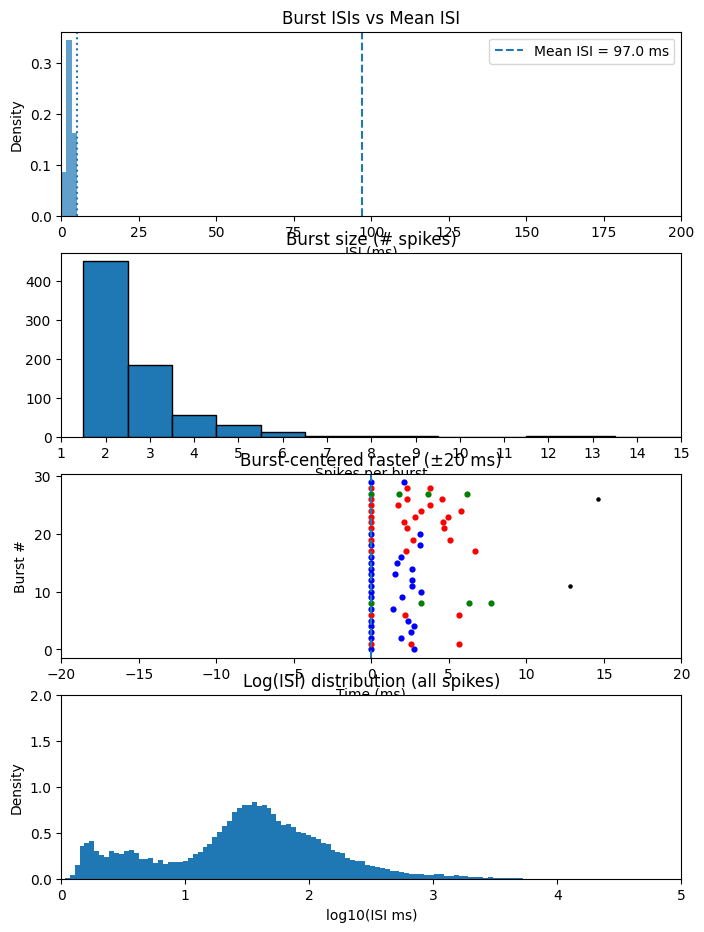

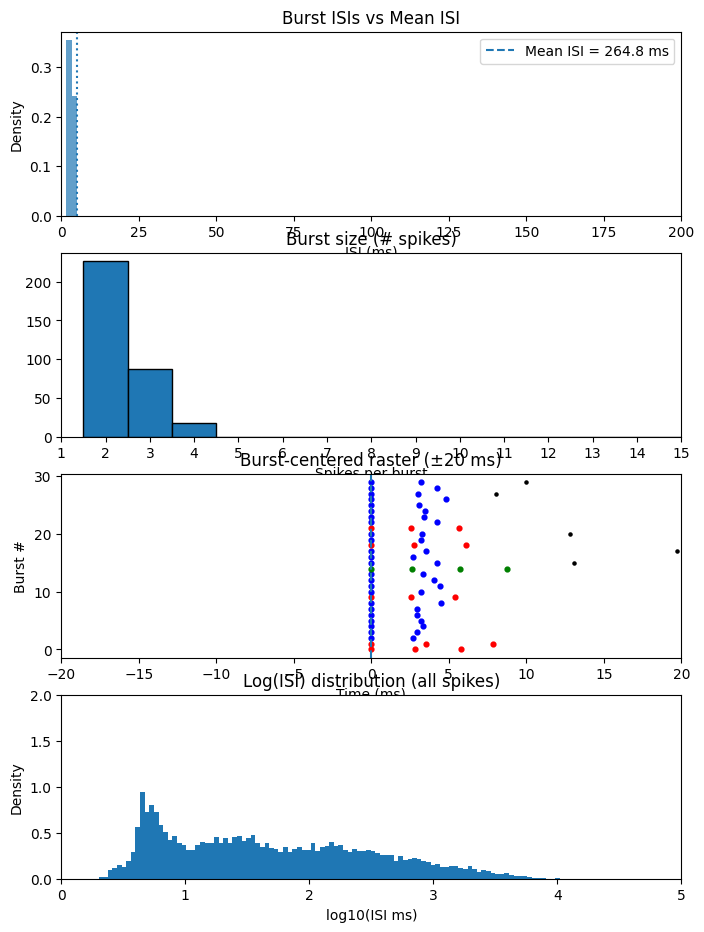

In [11]:
# =========================
# CELL B: BURST ANALYSIS MODULE
# =========================

import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import pandas as pd
import os

# =========================
# 1. LOAD SORTING + CURATION
# =========================
sorting = se.read_phy(phy_path)

cg_path = os.path.join(phy_path, "cluster_group.tsv")
df = pd.read_csv(cg_path, sep="\t")

good_cluster_ids = set(df[df["group"] == "good"]["cluster_id"].values)
unit_ids_all = sorting.get_unit_ids()

good_units = [u for u in unit_ids_all if u in good_cluster_ids]
sorting_good = sorting.select_units(good_units)

unit_ids = sorting_good.get_unit_ids()
sf = sorting_good.get_sampling_frequency()

print("✅ Units loaded:", len(unit_ids))


# =========================
# 2. BURST DETECTOR
# =========================
def detect_bursts(spike_times, 
                  min_quiet=0.100,
                  max_isi=0.005,
                  min_spikes=2):

    spike_times = np.asarray(spike_times)
    n = len(spike_times)

    bursts = []
    i = 0

    while i < n - 1:

        if i == 0:
            prev_isi = np.inf
        else:
            prev_isi = spike_times[i] - spike_times[i - 1]

        if prev_isi >= min_quiet:

            burst_spikes = [spike_times[i]]
            j = i

            while j < n - 1 and (spike_times[j + 1] - spike_times[j]) <= max_isi:
                burst_spikes.append(spike_times[j + 1])
                j += 1

            if len(burst_spikes) >= min_spikes:
                bursts.append({
                    "start": burst_spikes[0],
                    "end": burst_spikes[-1],
                    "n_spikes": len(burst_spikes),
                    "spikes": np.array(burst_spikes)
                })
                i = j + 1
                continue

        i += 1

    return bursts


# =========================
# 3. SORT UNITS BY SPIKE COUNT
# =========================
n_spikes_per_unit = np.array([
    len(sorting_good.get_unit_spike_train(u)) for u in unit_ids
])

sorted_units = [unit_ids[i] for i in np.argsort(n_spikes_per_unit)[::-1]]


# =========================
# 4. ANALYZE UNITS
# =========================
for unit in sorted_units:

    spike_train = sorting_good.get_unit_spike_train(unit)
    spike_times = spike_train / sf

    if len(spike_times) < 50:
        continue

    bursts = detect_bursts(spike_times)

    # ---- summary stats ----
    n_bursts = len(bursts)
    duration = spike_times[-1] - spike_times[0]
    burst_rate = n_bursts / duration if duration > 0 else 0

    spikes_in_bursts = sum([b["n_spikes"] for b in bursts])
    burst_fraction = spikes_in_bursts / len(spike_times)

    print(f"\nUnit {unit}")
    print(f"  spikes: {len(spike_times)}")
    print(f"  bursts: {n_bursts}")
    print(f"  burst rate: {burst_rate:.3f} Hz")
    print(f"  % spikes in bursts: {burst_fraction:.2%}")

    if n_bursts < 3:
        continue

    # =========================
    # 5. VISUALIZATION
    # =========================
    fig, axes = plt.subplots(4, 1, figsize=(8, 11))

    ax_isi, ax_burst, ax_examples, ax_logisi = axes

    # =========================
    # ISI COMPARISON (UNCHANGED STYLE)
    # =========================
    all_isis = np.diff(spike_times) * 1000  # ms

    burst_isis = []
    for b in bursts:
        if len(b["spikes"]) > 1:
            burst_isis.extend(np.diff(b["spikes"]) * 1000)

    burst_isis = np.array(burst_isis)

    max_isi_plot = 200
    burst_isis_plot = burst_isis[burst_isis < max_isi_plot]

    bins = np.linspace(0, max_isi_plot, 120)

    ax_isi.hist(burst_isis_plot, bins=bins, density=True, alpha=0.7)

    mean_isi = np.mean(all_isis)
    ax_isi.axvline(mean_isi, linestyle='--', label=f"Mean ISI = {mean_isi:.1f} ms")
    ax_isi.axvline(5, linestyle=':')

    ax_isi.set_xlim(0, max_isi_plot)
    ax_isi.set_title("Burst ISIs vs Mean ISI")
    ax_isi.set_xlabel("ISI (ms)")
    ax_isi.set_ylabel("Density")
    ax_isi.legend()

    # =========================
    # BURST SIZE HISTOGRAM (FIXED Y-AXIS)
    # =========================
    burst_sizes = [b["n_spikes"] for b in bursts]

    bins = np.arange(1.5, 16.5, 1)
    ax_burst.hist(burst_sizes, bins=bins, edgecolor='black')

    ax_burst.set_xlim(1, 15)
    ax_burst.set_xticks(np.arange(1, 16, 1))
    # let matplotlib handle y-axis automatically

    ax_burst.set_title("Burst size (# spikes)")
    ax_burst.set_xlabel("Spikes per burst")

    # =========================
    # EXAMPLE BURSTS (±20 ms)
    # =========================
    window = 0.02

    color_map = {2: 'blue', 3: 'red', 4: 'green'}
    color_5plus = 'purple'

    for i, b in enumerate(bursts[:30]):

        t0 = b["start"]
        rel = spike_times - t0

        mask = (rel > -window) & (rel < window)
        rel_window = rel[mask] * 1000

        ax_examples.scatter(rel_window, np.ones_like(rel_window)*i, s=5, color='black')

        burst_rel = (b["spikes"] - t0) * 1000
        c = color_map.get(b["n_spikes"], color_5plus)

        ax_examples.scatter(burst_rel, np.ones_like(burst_rel)*i, s=12, color=c)

    ax_examples.axvline(0, linestyle='--')
    ax_examples.set_xlim(-20, 20)

    ax_examples.set_title("Burst-centered raster (±20 ms)")
    ax_examples.set_xlabel("Time (ms)")
    ax_examples.set_ylabel("Burst #")

    # =========================
    # NEW: LOG(ISI) HISTOGRAM (ALL SPIKES)
    # =========================
    valid_isis = all_isis[all_isis > 0]
    log_isis = np.log10(valid_isis)

    ax_logisi.hist(log_isis, bins=100, density=True)

    # FIXED AXES (consistent across units)
    ax_logisi.set_xlim(0, 5)
    ax_logisi.set_ylim(0, 2.0)

    ax_logisi.set_title("Log(ISI) distribution (all spikes)")
    ax_logisi.set_xlabel("log10(ISI ms)")
    ax_logisi.set_ylabel("Density")